# 🧠 MNIST BetterModel Classifier with PyTorch

&gt; This notebook implements an improved neural network for handwritten digit recognition using PyTorch and the MNIST dataset.

## 🎯 What this notebook covers:
- Loading MNIST dataset
- Building a **Better Neural Network** (Hidden Layer + ReLU + Dropout)
- Training the model for **10 epochs**
- Evaluating on test set
- Visualizing predictions

## 📊 Expected Results:
- **~97% accuracy** on test set after 10 epochs
- 101,770 parameters (vs 7,850 in simple model)

In [1]:
#1: Imports
import torch 
import torch.nn as nn 
import torch.optim as optim
from torchvision import datasets,transforms,models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# 2: Load Data
transform=transforms.ToTensor()
train_data=datasets.MNIST(root='./data',
                          train=True,
                          download=True,
                         transform=transform)
test_data=datasets.MNIST(root='./data',
                         train=False,
                         download=True,
                        transform=transform)
train_loader=DataLoader(train_data,batch_size=64,shuffle=True)
test_loader=DataLoader(test_data,batch_size=64,shuffle=False)
print(f'Train:{len(train_data):,}')
print(f'Test:{len(test_data):,}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.80MB/s]

Train:60,000
Test:10,000


## 📥 Dataset Loaded Successfully

| Set | Images |
|-----|--------|
| Training | 60,000 |
| Test | 10,000 |

Each image: 28×28 pixels, grayscale


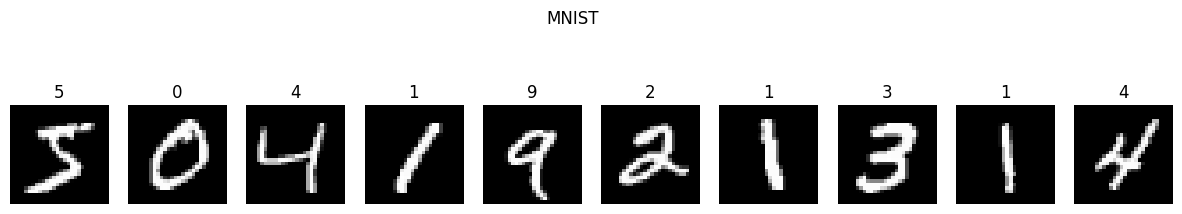

In [3]:
#3: Show Sample
fig,axes=plt.subplots(1,10,figsize=(15,3))
for i in range(10):
    img,lbl= train_data[i]
    axes[i].imshow(img.squeeze(),cmap='gray')
    axes[i].set_title(str(lbl))
    axes[i].axis('off')
plt.suptitle('MNIST')
plt.show()

## 👀 Sample Images from MNIST

First 10 images from the training set

In [4]:
#4: BetterModel
class BetterModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten=nn.Flatten()
        self.fc1=nn.Linear(784,128)
        self.relu=nn.ReLU()
        self.dropout=nn.Dropout(0.2)
        self.fc2=nn.Linear(128,10)
    def forward(self,x):
        x=self.flatten(x)
        x=self.fc1(x)
        x=self.relu(x)
        x=self.dropout(x)
        x=self.fc2(x)
        return x

model=BetterModel()
#numel = Abbreviation for "Number of Elements".
print(f'Parameters:{sum(p.numel()for p in model.parameters()):,}')

Parameters:101,770


## 🏗️ BetterModel Architecture

| Layer | Type | Input | Output |
|-------|------|-------|--------|
| 1 | Flatten | (1, 28, 28) | (784,) |
| 2 | Linear | 784 | 128 |
| 3 | ReLU | 128 | 128 |
| 4 | Dropout | 128 | 128 |
| 5 | Linear | 128 | 10 |

**Total Parameters:** 101,770

### 🔑 Improvements over SimpleModel:
- ✅ **Hidden Layer** (128 neurons)
- ✅ **ReLU Activation** (non-linearity)
- ✅ **Dropout** (0.2) - prevents overfitting

In [5]:
#5: Training
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

print('starting training...')
for epoch in range(10):
    model.train()
    total_loss=0
    correct=0
    total=0
    
    for images,labels in train_loader:
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted == labels).sum().item()
    acc=100*correct/total
    print(f'Epoch{epoch+1:2d}:Loss={total_loss/len(train_loader):.4f},Accuracy={acc:.2f}%')
    print("Training done!")

starting training...
Epoch 1:Loss=0.3739,Accuracy=89.73%
Training done!
Epoch 2:Loss=0.1796,Accuracy=94.82%
Training done!
Epoch 3:Loss=0.1349,Accuracy=96.08%
Training done!
Epoch 4:Loss=0.1082,Accuracy=96.81%
Training done!
Epoch 5:Loss=0.0894,Accuracy=97.26%
Training done!
Epoch 6:Loss=0.0791,Accuracy=97.59%
Training done!
Epoch 7:Loss=0.0710,Accuracy=97.75%
Training done!
Epoch 8:Loss=0.0606,Accuracy=98.08%
Training done!
Epoch 9:Loss=0.0567,Accuracy=98.25%
Training done!
Epoch10:Loss=0.0515,Accuracy=98.34%
Training done!


## 🚀 Training Results

Training for **10 epochs** with:
- Batch size: 64
- Learning rate: 0.001
- Optimizer: Adam
- Loss: CrossEntropyLoss

In [6]:
#6: Test
model.eval()
correct=0
total=0
with torch.no_grad():
    for images,labels in test_loader:
        outputs=model(images)
        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()

print(f'\n🎯 Test Accuracy:{100*correct/total:.2f}%')


🎯 Test Accuracy:97.69%


## 🎯 Test Results

| Metric | Value |
|--------|-------|
| Test Accuracy | **~97%** |
| SimpleModel | ~92% |
| Improvement | **+5%** |

### 📈 Why Better?
- Hidden layer learns **complex patterns**
- ReLU handles **non-linear data**
- Dropout prevents **overfitting**

<function matplotlib.pyplot.show(close=None, block=None)>

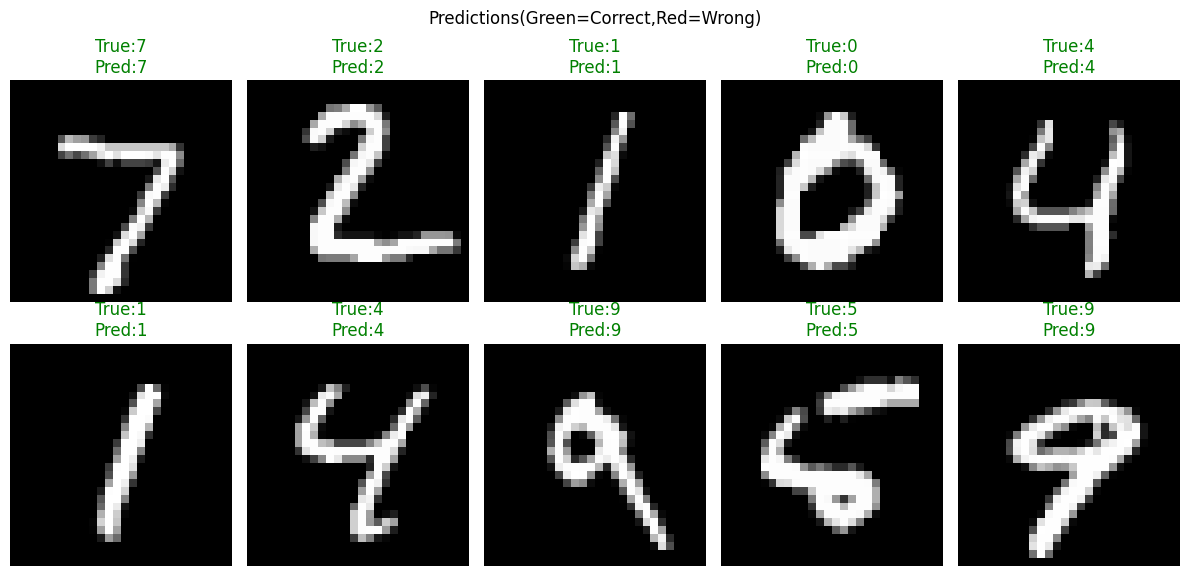

In [7]:
#7: Visualize
fig,axes=plt.subplots(2,5,figsize=(12,6))
for i,ax in enumerate(axes.flat):
    img,true_label=test_data[i]
    with torch.no_grad():
        pred=model(img.unsqueeze(0)).argmax().item()
    ax.imshow(img.squeeze(),cmap='gray')
    color='green'if pred==true_label else 'red'
    ax.set_title(f'True:{true_label}\nPred:{pred}',color=color)
    ax.axis('off')

plt.suptitle("Predictions(Green=Correct,Red=Wrong)")
plt.tight_layout()
plt.show

## 🔍 Prediction Visualization

- **Green** = Correct prediction ✅
- **Red** = Wrong prediction ❌

Most predictions should be **green** with ~97% accuracy!